### Task 1: Designing a Heuristic for a Warehouse Robot

In [36]:
import math
import networkx as nx
import matplotlib.pyplot as plt


# 1. Coordinates of warehouse locations

locations = {
    "Receiving_Area": (0, 0),
    "Storage_A": (2, 1),
    "Storage_B": (1, 4),
    "Sorting_Area": (4, 2),
    "Inspection_Area": (5, 5),
    "Packing_Station": (7, 6)
}


# 2. Weighted warehouse graph

warehouse_graph = {
    "Receiving_Area": {
        "Storage_A": 2.2,
        "Storage_B": 4.1
    },

    "Storage_A": {
        "Sorting_Area": 2.2
    },

    "Storage_B": {
        "Inspection_Area": 5.0,
        "Sorting_Area": 6.0
    },

    "Sorting_Area": {
        "Inspection_Area": 3.2,
        "Packing_Station": 5.0
    },

    "Inspection_Area": {
        "Packing_Station": 2.2
    },

    "Packing_Station": {}
}


# 3. Euclidean heuristic

def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


# 4. Calculate heuristic values

goal = "Packing_Station"

print("Heuristic Values")
print("----------------")
print(f"{'Location':20s}{'h(n)':>10s}")

for location in locations:
    print(f"{location:20s}{heuristic(location, goal):10.2f}")


Heuristic Values
----------------
Location                  h(n)
Receiving_Area            9.22
Storage_A                 7.07
Storage_B                 6.32
Sorting_Area              5.00
Inspection_Area           2.24
Packing_Station           0.00


#### NetworkX visualization: Since Task 1 does not ask GBFS/A* to find a path, you are supposed highlight the actual minimum-cost path merely for visualization:

In [37]:
# 5. Create NetworkX graph

G = nx.DiGraph()

for node, neighbors in warehouse_graph.items():
    G.add_node(node, pos=locations[node])
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

# 6. Find minimum-cost path

solution_path = nx.shortest_path(
    G,
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight"
)

solution_cost = nx.shortest_path_length(
    G,
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight"
)

print("\nMinimum cost path:")
print(" -> ".join(solution_path))
print(f"Total cost: {solution_cost:.2f}")



Minimum cost path:
Receiving_Area -> Storage_A -> Sorting_Area -> Packing_Station
Total cost: 9.40


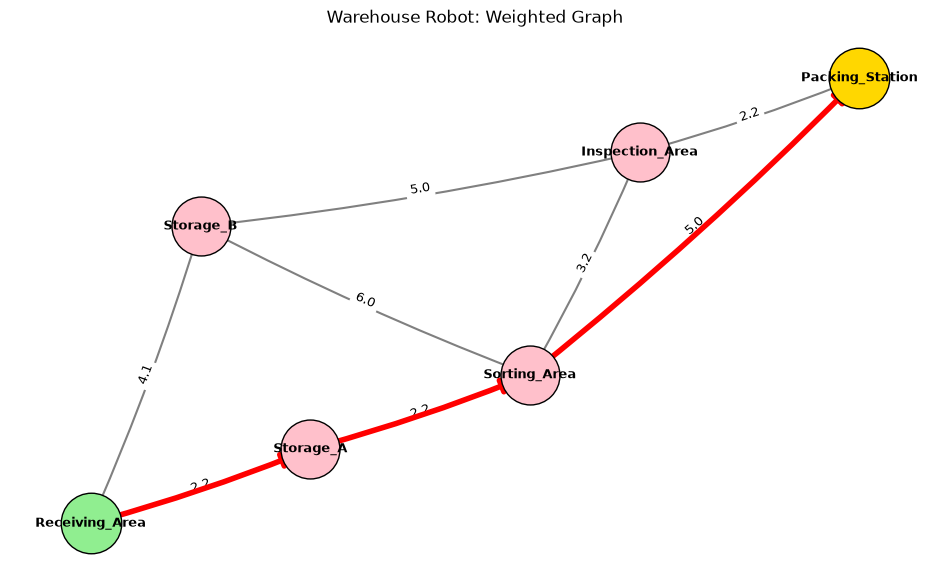

In [38]:
# 7. Visualize graph

pos = locations

plt.figure(figsize=(12, 7))

nx.draw_networkx_nodes(
    G, pos,
    node_color="pink",
    node_size=1800,
    edgecolors="black"
)

nx.draw_networkx_labels(
    G, pos,
    font_size=9,
    font_weight="bold"
)

nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    arrows=True,
    arrowsize=18,
    width=1.5,
    connectionstyle="arc3,rad=0.03"
)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=9
)

solution_edges = list(zip(solution_path[:-1], solution_path[1:]))

nx.draw_networkx_edges(
    G, pos,
    edgelist=solution_edges,
    edge_color="red",
    width=4,
    arrows=True,
    arrowsize=22,
    connectionstyle="arc3,rad=0.03"
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=[solution_path[0]],
    node_color="lightgreen",
    node_size=1900,
    edgecolors="black"
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=[solution_path[-1]],
    node_color="gold",
    node_size=1900,
    edgecolors="black"
)

plt.title("Warehouse Robot: Weighted Graph")
plt.axis("off")
plt.show()


In [39]:
# 8. Verify heuristic condition

print("\nHeuristic Condition Verification")
print("Condition: h(n) <= cost(n,m) + h(m)")

all_satisfied = True

for node in warehouse_graph:
    for neighbor, cost in warehouse_graph[node].items():
        h_node = heuristic(node, goal)
        rhs = cost + heuristic(neighbor, goal)
        satisfied = h_node <= rhs + 1e-9
        all_satisfied = all_satisfied and satisfied

        status = "Satisfied" if satisfied else "Not satisfied"
        print(
            f"{node} to {neighbor}: "
            f"{h_node:.2f} <= {cost:.2f} + {heuristic(neighbor, goal):.2f} "
            f"= {rhs:.2f} : {status}"
        )

print(
    "\nOverall result:",
    "the heuristic condition is satisfied for all given edges."
    if all_satisfied
    else "the heuristic condition is not satisfied for every edge."
)



Heuristic Condition Verification
Condition: h(n) <= cost(n,m) + h(m)
Receiving_Area to Storage_A: 9.22 <= 2.20 + 7.07 = 9.27 : Satisfied
Receiving_Area to Storage_B: 9.22 <= 4.10 + 6.32 = 10.42 : Satisfied
Storage_A to Sorting_Area: 7.07 <= 2.20 + 5.00 = 7.20 : Satisfied
Storage_B to Inspection_Area: 6.32 <= 5.00 + 2.24 = 7.24 : Satisfied
Storage_B to Sorting_Area: 6.32 <= 6.00 + 5.00 = 11.00 : Satisfied
Sorting_Area to Inspection_Area: 5.00 <= 3.20 + 2.24 = 5.44 : Satisfied
Sorting_Area to Packing_Station: 5.00 <= 5.00 + 0.00 = 5.00 : Satisfied
Inspection_Area to Packing_Station: 2.24 <= 2.20 + 0.00 = 2.20 : Not satisfied

Overall result: the heuristic condition is not satisfied for every edge.


Observation: Euclidean distance is suitable because it estimates the remaining straight-line distance to the goal, and for the given graph its values satisfy the required edge condition.\n

### Task 2: Greedy Best-First Search for Airport Baggage Handling

In [40]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# 1. Airport coordinates

locations = {
    "Baggage_Area": (0, 0),
    "Security": (2, 1),
    "Checkpoint": (1, 4),
    "Food_Court": (4, 2),
    "Terminal_Hall": (5, 5),
    "Departure_Gate": (8, 6)
}

# 2. Weighted graph

airport_graph = {
    "Baggage_Area": {
        "Security": 2.2,
        "Checkpoint": 4.1
    },

    "Security": {
        "Food_Court": 2.2
    },

    "Checkpoint": {
        "Terminal_Hall": 5.0
    },

    "Food_Court": {
        "Terminal_Hall": 3.2,
        "Departure_Gate": 6.0
    },

    "Terminal_Hall": {
        "Departure_Gate": 3.2
    },

    "Departure_Gate": {}
}

# 3. Euclidean heuristic

def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


# 4. GBFS

def greedy_best_first_search(start, goal, graph):
    frontier = []
    counter = 0

    heapq.heappush(frontier, (heuristic(start, goal), counter, start))

    came_from = {}
    visited = set()
    expansion_order = []

    while frontier:
        _, _, current = heapq.heappop(frontier)

        if current in visited:
            continue

        visited.add(current)
        expansion_order.append(current)

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()

            total_cost = sum(
                graph[path[i]][path[i + 1]]
                for i in range(len(path) - 1)
            )

            return path, total_cost, expansion_order

        for neighbor in graph[current]:
            if neighbor not in visited:
                counter += 1
                came_from.setdefault(neighbor, current)
                heapq.heappush(
                    frontier,
                    (heuristic(neighbor, goal), counter, neighbor)
                )

    return None, float("inf"), expansion_order


# 5. Run GBFS

start = "Baggage_Area"
goal = "Departure_Gate"

path, total_cost, expansion_order = greedy_best_first_search(
    start,
    goal,
    airport_graph
)

print("GBFS")

print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")


GBFS
Expansion order:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Solution path:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Total path cost: 12.30


#### NetworkX visualization

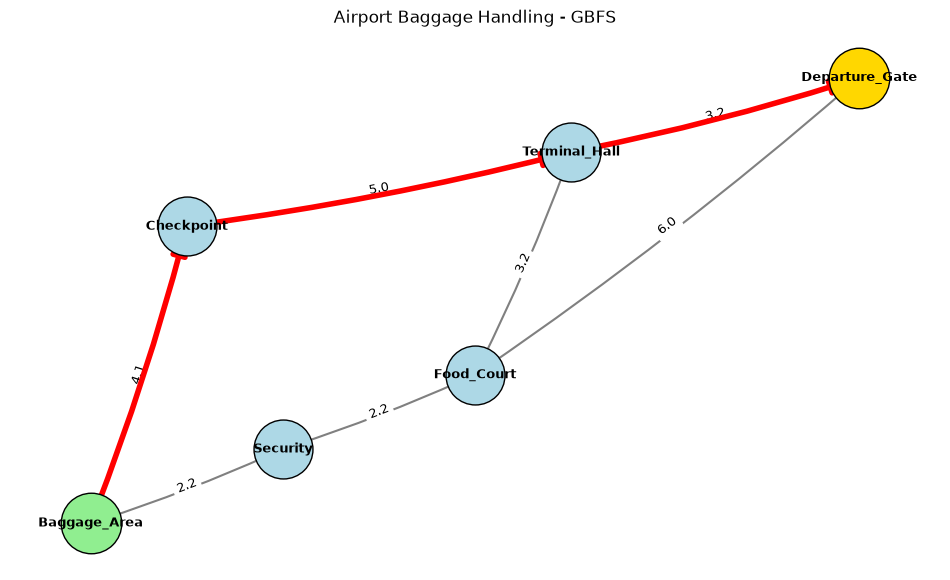

In [41]:
# 6. NetworkX visualization

G = nx.DiGraph()

for node, neighbors in airport_graph.items():
    G.add_node(node, pos=locations[node])
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

pos = locations

plt.figure(figsize=(12, 7))

nx.draw_networkx_nodes(
    G, pos,
    node_color="lightblue",
    node_size=1800,
    edgecolors="black"
)

nx.draw_networkx_labels(
    G, pos,
    font_size=9,
    font_weight="bold"
)

nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    arrows=True,
    arrowsize=18,
    width=1.5,
    connectionstyle="arc3,rad=0.03"
)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=9
)

solution_edges = list(zip(path[:-1], path[1:]))

nx.draw_networkx_edges(
    G, pos,
    edgelist=solution_edges,
    edge_color="red",
    width=4,
    arrows=True,
    arrowsize=22,
    connectionstyle="arc3,rad=0.03"
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=[start],
    node_color="lightgreen",
    node_size=1900,
    edgecolors="black"
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=[goal],
    node_color="gold",
    node_size=1900,
    edgecolors="black"
)

plt.title("Airport Baggage Handling - GBFS")
plt.axis("off")
plt.show()


### Task 3: A* Search for Emergency Supply Robot

In [42]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt


# 1. Hospital coordinates

locations = {
    "Pharmacy": (0, 0),
    "Main_Corridor": (2, 1),
    "Patient_Wing": (1, 4),
    "Nursing_Station": (4, 2),
    "Laboratory": (5, 5),
    "Emergency_Ward": (8, 6)
}


# 2. Hospital weighted graph

hospital_graph = {
    "Pharmacy": {
        "Main_Corridor": 2.2,
        "Patient_Wing": 4.1
    },

    "Main_Corridor": {
        "Nursing_Station": 2.2
    },

    "Patient_Wing": {
        "Laboratory": 5.0
    },

    "Nursing_Station": {
        "Laboratory": 3.2,
        "Emergency_Ward": 6.0
    },

    "Laboratory": {
        "Emergency_Ward": 3.2
    },

    "Emergency_Ward": {}
}

# 3. Euclidean heuristic

def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


# 4. Path reconstruction

def reconstruct_path(came_from, current):
    path = [current]

    while current in came_from:
        current = came_from[current]
        path.append(current)

    path.reverse()
    return path


# 5. A* Search

def a_star_search(start, goal, graph):
    frontier = []
    counter = 0

    g_cost = {start: 0.0}
    came_from = {}
    expansion_order = []
    expanded_best_g = {}

    heapq.heappush(
        frontier,
        (heuristic(start, goal), counter, start)
    )

    while frontier:
        f_value, _, current = heapq.heappop(frontier)
        current_g = g_cost[current]

        # Ignore stale queue entries.
        if current in expanded_best_g and current_g > expanded_best_g[current] + 1e-9:
            continue

        expanded_best_g[current] = current_g
        expansion_order.append(current)

        if current == goal:
            path = reconstruct_path(came_from, current)
            return path, current_g, expansion_order, g_cost

        for neighbor, edge_cost in graph[current].items():
            tentative_g = current_g + edge_cost

            if tentative_g < g_cost.get(neighbor, float("inf")):
                g_cost[neighbor] = tentative_g
                came_from[neighbor] = current

                counter += 1
                f_neighbor = tentative_g + heuristic(neighbor, goal)

                heapq.heappush(
                    frontier,
                    (f_neighbor, counter, neighbor)
                )

    return None, float("inf"), expansion_order, g_cost


# 6. Run A*

start = "Pharmacy"
goal = "Emergency_Ward"

path, total_cost, expansion_order, g_cost = a_star_search(
    start,
    goal,
    hospital_graph
)

print("A* Search")
print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")


A* Search
Expansion order:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Solution path:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Total path cost: 10.40


#### g(n), h(n), f(n) table

In [ ]:
print("\nA* Node Information")
print(
    f"{'Node':20s}"
    f"{'g(n)':>10s}"
    f"{'h(n)':>10s}"
    f"{'f(n)':>10s}"
)

for node in expansion_order:
    g = g_cost[node]
    h = heuristic(node, goal)
    f = g + h

    print(
        f"{node:20s}"
        f"{g:10.2f}"
        f"{h:10.2f}"
        f"{f:10.2f}"
    )



A* Node Information
*********************
Node                      g(n)      h(n)      f(n)
Pharmacy                  0.00     10.00     10.00
Main_Corridor             2.20      7.81     10.01
Nursing_Station           4.40      5.66     10.06
Emergency_Ward           10.40      0.00     10.40


#### NetworkX visualization

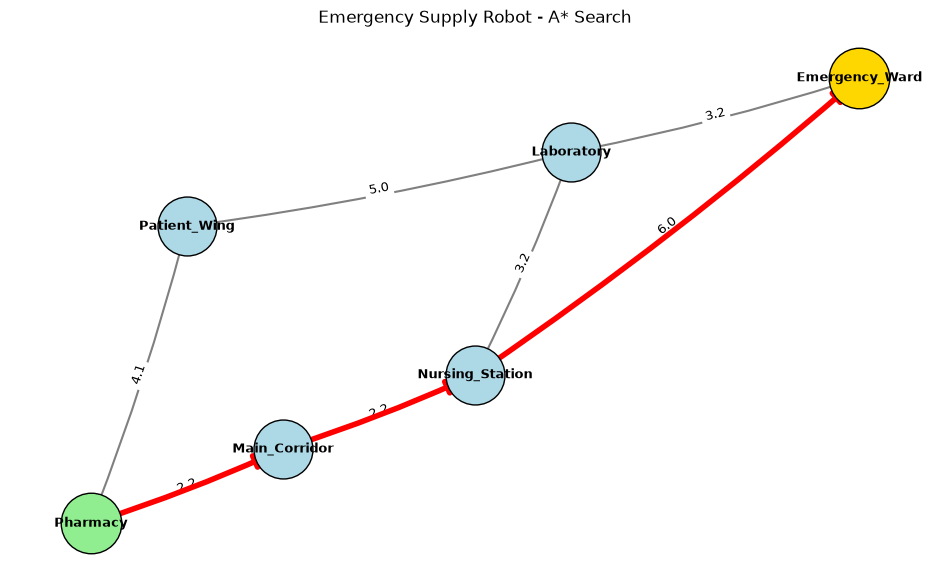

In [44]:
# 7. NetworkX visualization

G = nx.DiGraph()

for node, neighbors in hospital_graph.items():
    G.add_node(node, pos=locations[node])
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

pos = locations

plt.figure(figsize=(12, 7))

nx.draw_networkx_nodes(
    G, pos,
    node_color="lightblue",
    node_size=1800,
    edgecolors="black"
)

nx.draw_networkx_labels(
    G, pos,
    font_size=9,
    font_weight="bold"
)

nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    arrows=True,
    arrowsize=18,
    width=1.5,
    connectionstyle="arc3,rad=0.03"
)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=9
)

solution_edges = list(zip(path[:-1], path[1:]))

nx.draw_networkx_edges(
    G, pos,
    edgelist=solution_edges,
    edge_color="red",
    width=4,
    arrows=True,
    arrowsize=22,
    connectionstyle="arc3,rad=0.03"
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=[start],
    node_color="lightgreen",
    node_size=1900,
    edgecolors="black"
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=[goal],
    node_color="gold",
    node_size=1900,
    edgecolors="black"
)

plt.title("Emergency Supply Robot - A* Search")
plt.axis("off")
plt.show()


GBFS would primarily ask: “Which node appears closest to the Emergency Ward?”

A* instead asks: “Considering both the cost already travelled and the estimated remaining cost, which node has the lowest estimated total cost?”

Observation: GBFS uses only h(n), while A* uses g(n) + h(n), so A* also accounts for the actual cost already spent reaching a node. This can change which frontier node is selected.


### Task 4: Weighted A* for Autonomous Delivery Drone

In [45]:
import math
import heapq
import pandas as pd

# 1. Location Coordinates

locations = {
    "Distribution_Center": (0, 0),
    "Zone_A": (2, 1),
    "Zone_B": (1, 4),
    "Zone_C": (4, 2),
    "Zone_D": (5, 5),
    "Customer_Building": (8, 6)
}

# 2. Weighted Graph

graph = {
    "Distribution_Center": {
        "Zone_A": 2.2,
        "Zone_B": 3.0
    },

    "Zone_A": {
        "Zone_C": 2.2
    },

    "Zone_B": {
        "Zone_D": 5.0
    },

    "Zone_C": {
        "Zone_D": 3.2,
        "Customer_Building": 6.0
    },

    "Zone_D": {
        "Customer_Building": 3.2
    },

    "Customer_Building": {}
}

# 3. Euclidean Heuristic

def heuristic(node, goal):
    x1, y1 = locations[node]
    x2, y2 = locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


# 4. Display Heuristic Values

goal = "Customer_Building"

heuristic_data = []

for node in locations:
    heuristic_data.append({
        "Node": node,
        "h(n)": round(heuristic(node, goal), 2)
    })

heuristic_df = pd.DataFrame(heuristic_data)

print("Heuristic Values:")
print(heuristic_df.to_string(index=False))

# 5. Weighted A* Search
# f(n) = g(n) + w * h(n)

def weighted_a_star(start, goal, graph, weight):
    frontier = []
    counter = 0

    g_cost = {start: 0.0}
    came_from = {}
    expansion_order = []
    expanded_best_g = {}

    heapq.heappush(
        frontier,
        (weight * heuristic(start, goal), counter, start)
    )

    while frontier:
        _, _, current = heapq.heappop(frontier)
        current_g = g_cost[current]

        if current in expanded_best_g and current_g > expanded_best_g[current] + 1e-9:
            continue

        expanded_best_g[current] = current_g
        expansion_order.append(current)

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)

            path.reverse()
            return path, current_g, expansion_order

        for neighbor, edge_cost in graph[current].items():
            tentative_g = current_g + edge_cost

            if tentative_g < g_cost.get(neighbor, float("inf")):
                g_cost[neighbor] = tentative_g
                came_from[neighbor] = current

                counter += 1
                f_value = tentative_g + weight * heuristic(neighbor, goal)

                heapq.heappush(
                    frontier,
                    (f_value, counter, neighbor)
                )

    return None, float("inf"), expansion_order


# 6. Run Weighted A* for All Required Weights

start = "Distribution_Center"
goal = "Customer_Building"

weights = [1, 1.5, 2, 3]

results = []

for w in weights:
    path, cost, expansion_order = weighted_a_star(
        start,
        goal,
        graph,
        w
    )

    results.append({
        "Weight": w,
        "Solution Path": " → ".join(path),
        "Total Cost": round(cost, 2),
        "Nodes Expanded": len(expansion_order),
        "Expansion Order": " → ".join(expansion_order)
    })


# 7. Display Results in dataframe

results_df = pd.DataFrame(results)

print("\nWeighted A* Results:")
print(
    results_df[
        ["Weight", "Solution Path", "Total Cost", "Nodes Expanded"]
    ].to_string(index=False)
)

# 8. Display Detailed Expansion Orders

print("\nExpansion Orders:")
for result in results:
    print(f"w = {result['Weight']}: {result['Expansion Order']}")


# ***
# Expected Main Results
# ***

# w = 1:
# Distribution_Center → Zone_A → Zone_C → Customer_Building
# Cost = 10.4
#
# w = 1.5:
# Distribution_Center → Zone_A → Zone_C → Customer_Building
# Cost = 10.4
#
# w = 2:
# Distribution_Center → Zone_B → Zone_D → Customer_Building
# Cost = 11.2
#
# w = 3:
# Distribution_Center → Zone_B → Zone_D → Customer_Building
# Cost = 11.2


Heuristic Values:
               Node  h(n)
Distribution_Center 10.00
             Zone_A  7.81
             Zone_B  7.28
             Zone_C  5.66
             Zone_D  3.16
  Customer_Building  0.00

Weighted A* Results:
 Weight                                             Solution Path  Total Cost  Nodes Expanded
    1.0 Distribution_Center → Zone_A → Zone_C → Customer_Building        10.4               5
    1.5 Distribution_Center → Zone_A → Zone_C → Customer_Building        10.4               4
    2.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4
    3.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4

Expansion Orders:
w = 1: Distribution_Center → Zone_A → Zone_C → Zone_B → Customer_Building
w = 1.5: Distribution_Center → Zone_A → Zone_C → Customer_Building
w = 2: Distribution_Center → Zone_B → Zone_D → Customer_Building
w = 3: Distribution_Center → Zone_B → Zone_D → Customer_Building


#### NetworkX visualization

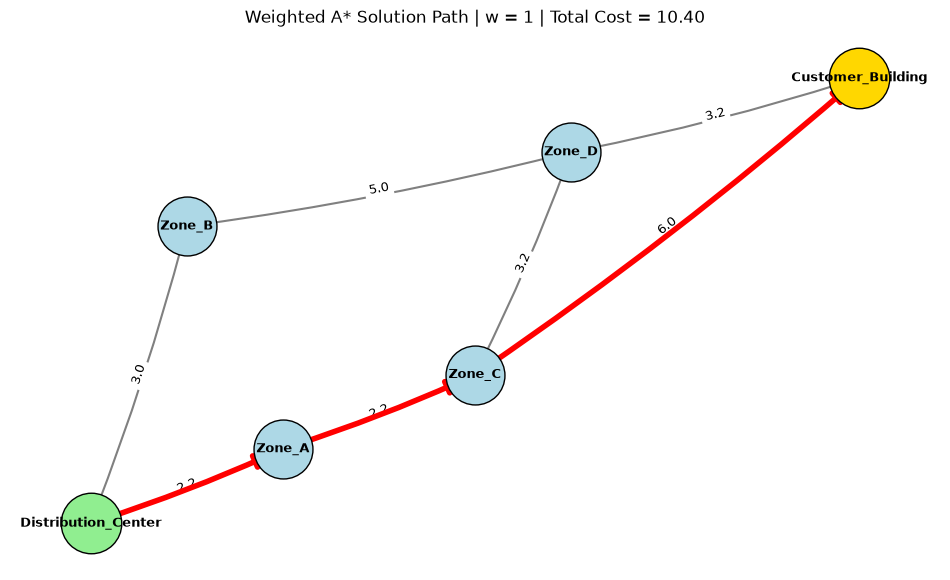

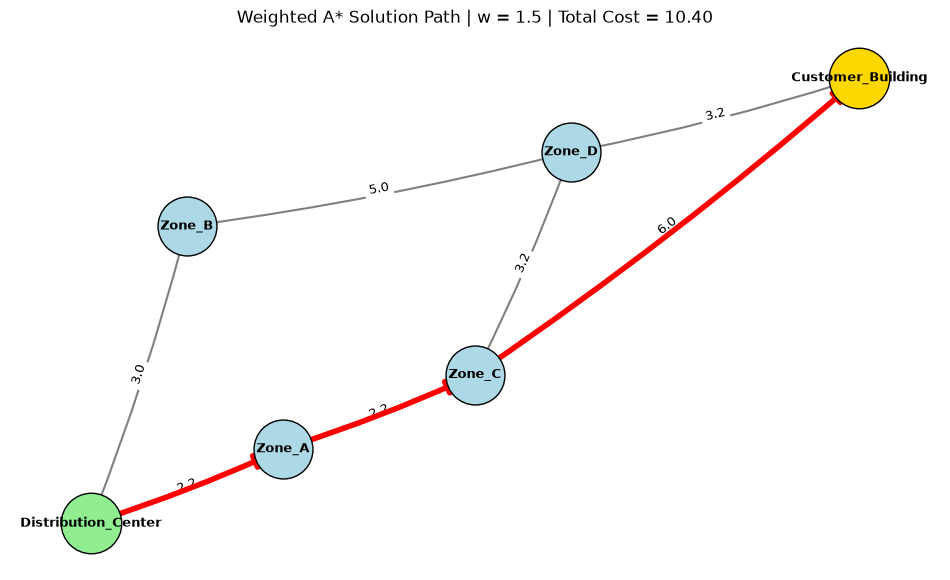

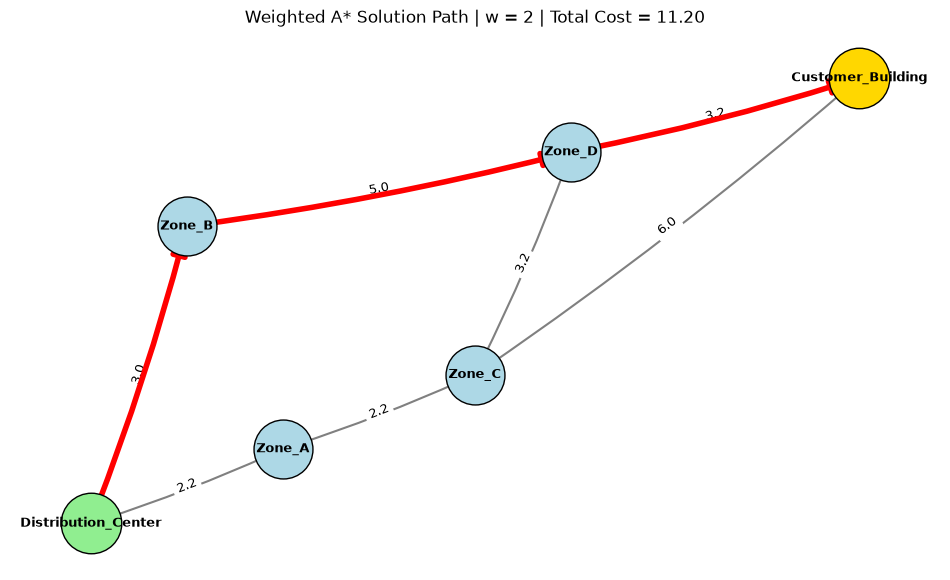

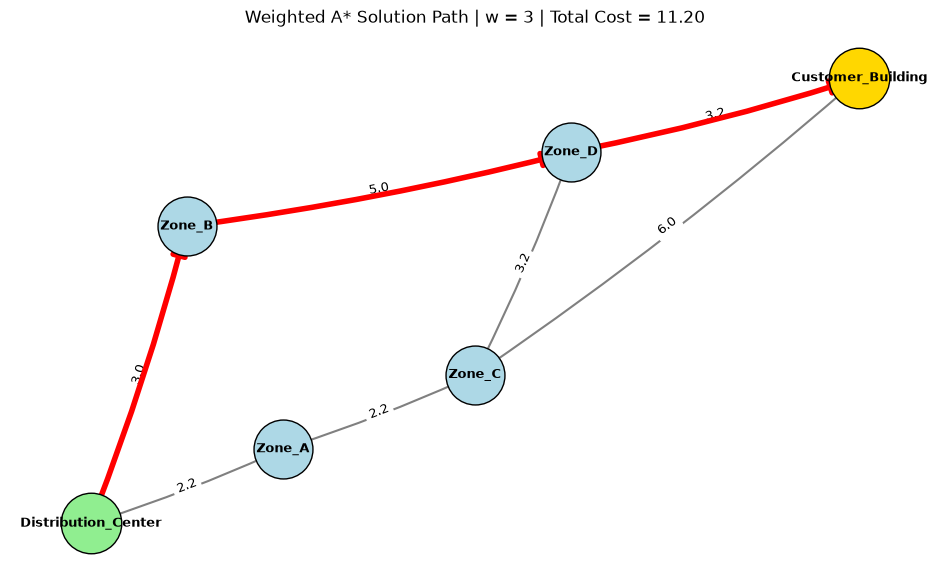

In [46]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create NetworkX Graph

G = nx.DiGraph()

for node, position in locations.items():
    G.add_node(
        node,
        pos=position
    )

for node, neighbors in graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)

# 2. Node Positions

pos = locations

# 3. Visualize Weighted A* Result for Each Weight

for w in weights:
    path, cost, expansion_order = weighted_a_star(
        start,
        goal,
        graph,
        w
    )

    plt.figure(figsize=(12, 7))

    nx.draw_networkx_nodes(
        G, pos,
        node_color="lightblue",
        node_size=1800,
        edgecolors="black"
    )

    nx.draw_networkx_labels(
        G, pos,
        font_size=9,
        font_weight="bold"
    )

    nx.draw_networkx_edges(
        G, pos,
        edge_color="gray",
        arrows=True,
        arrowsize=18,
        width=1.5,
        connectionstyle="arc3,rad=0.03"
    )

    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_size=9
    )

    solution_edges = list(zip(path[:-1], path[1:]))

    nx.draw_networkx_edges(
        G, pos,
        edgelist=solution_edges,
        edge_color="red",
        width=4,
        arrows=True,
        arrowsize=22,
        connectionstyle="arc3,rad=0.03"
    )

    nx.draw_networkx_nodes(
        G, pos,
        nodelist=[start],
        node_color="lightgreen",
        node_size=1900,
        edgecolors="black"
    )

    nx.draw_networkx_nodes(
        G, pos,
        nodelist=[goal],
        node_color="gold",
        node_size=1900,
        edgecolors="black"
    )

    plt.title(
        f"Weighted A* Solution Path | w = {w} | "
        f"Total Cost = {cost:.2f}"
    )

    plt.axis("off")
    plt.show()


#### Interpretation

As w increases, the heuristic h(n) receives more weight in the evaluation function f(n) = g(n) + w*h(n). For this graph, w = 1 and w = 1.5 return the 10.4-cost route, while w = 2 and w = 3 select the 11.2-cost route. Thus, giving more importance to the heuristic changes the search behavior and can reduce exploration, but w > 1 does not guarantee the optimal path.
